<a href="https://colab.research.google.com/github/jdiaz-DevEng/Inmersion_Agentes_De_AI_Dev/blob/main/Inmersion_IA_Dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
!pip install -q google-genai

In [48]:
from google.colab import userdata
import os
os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [49]:
from google import genai
cliente = genai.Client()

In [50]:
respuesta = cliente.models.generate_content(
    model = "gemini-2.5-flash",
    contents="¿Cual es la capital y la ciudad más grande de Turquia?"
)
print(respuesta.text)

La capital de Turquía es **Ankara** y su ciudad más grande es **Estambul**.


In [51]:
from google.colab import files

os.makedirs("PDFs", exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
   os.rename(archivo, f"PDFs/{archivo}")

Saving Carrarurquia_Reporte_Q1_2025.pdf to Carrarurquia_Reporte_Q1_2025.pdf
Saving Carrarurquia_Reporte_Q2_2025.pdf to Carrarurquia_Reporte_Q2_2025.pdf
Saving Carrarurquia_Reporte_Q3_2025.pdf to Carrarurquia_Reporte_Q3_2025.pdf
Saving Carrarurquia_Reporte_Q4_2025.pdf to Carrarurquia_Reporte_Q4_2025.pdf


In [52]:
!pip install -q langchain-community pypdf

In [53]:
from langchain_community.document_loaders import PyPDFLoader

In [54]:
documentos = []

for archivo2 in os.listdir("PDFs"):
  ruta = os.path.join("PDFs",archivo2)
  loader = PyPDFLoader(ruta)
  paginas = loader.load()
  documentos.extend(paginas)

In [55]:
documentos[0]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q2 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q2_2025.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Carrarurquía\nReporte trimestral Q2 2025 (ficticio)\nPeriodo: 01/04/2025 - 30/06/2025\nMoneda: USD\n1\n Carrarurquía\n Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)\n Periodo: 01/04/2025 - 30/06/2025\n Moneda de referencia: dólares estadounidenses (USD)\nEste documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una\nempresa de viajes especializada en experiencias en Turquía. Los datos, cifras y testimonios han sido\ncreados con fines demostrativos y no representan operaciones reales.\n Edición: Julio de 2025')

In [56]:
len(documentos)

60

In [57]:
!pip install -q langchain-text-splitters

In [58]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=["\n\n", "\n", ". ", " ", ""]
)

fragmentos = divisor.split_documents(documentos)

In [59]:
fragmentos[59]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q4 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q4_2025.pdf', 'total_pages': 15, 'page': 7, 'page_label': '8'}, page_content='Carrarurquía\nReporte trimestral Q4 2025 (ficticio)\nPeriodo: 01/10/2025 - 31/12/2025\nMoneda: USD\n8\n6. Marketing y adquisición\nInversión, eficiencia y aprendizaje\nSe evalúa la inversión por canal y su contribución al volumen confirmado. En el trimestre se priorizaron\nmensajes centrados en itinerarios con alta disponibilidad, reduciendo fricción operativa.\nMétrica\nValor\nInterpretación\nInversión total')

In [60]:
!pip install -q langchain-google-genai faiss-cpu

In [61]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

In [62]:
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:89],
    embedding=embeddings
)

In [63]:
vectorstore2 = FAISS.from_documents(
    documents=fragmentos[90:],
    embedding=embeddings
)

In [64]:
len (vectorstore1.index.reconstruct(0))

3072

In [65]:
vectorstore1.merge_from(vectorstore2)

In [66]:
consulta = "¿Cual es el paquete de viajes mas economico de Carrarurquia?"

resultados =vectorstore1.similarity_search(
    consulta,
    k=3
)

for i in resultados:
  print(i)
  print("\n")

page_content='Carrarurquía
Reporte trimestral Q3 2025 (ficticio)
Periodo: 01/07/2025 - 30/09/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación' metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q3 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q3_2025.pdf', 'total_pages': 15, 'page': 12, 'page_label': '13'}


page_content='Carrarurquía
Reporte trimestral Q2 2025 (ficticio)
Periodo: 01/04/2025 - 30/06/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran

In [67]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

recuperador=vectorstore1.as_retriever(
    search_kwargs={"k":4}
)


In [68]:
def preguntar_rag(pregunta):
    """Busca contexto relevante en los documentos y genera una respuesta."""
    # Paso 1: Buscar los chunks más relevantes
    docs = recuperador.invoke(pregunta)
    contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)

    # Paso 2: Construir el prompt con el contexto encontrado
    prompt = f"""Eres un asistente experto que responde preguntas basándose ÚNICAMENTE
    en el contexto proporcionado. Si la información no está en el contexto,
    di que no tienes suficiente información.

    Contexto: {contexto}

    Pregunta: {pregunta}

    Respuesta:"""

    # Paso 3: Enviar al modelo y devolver la respuesta
    respuesta = llm.invoke(prompt)
    return respuesta.content

    print("✅Función RAG creada exitosamente")

In [69]:
preguntar_rag("Donde se mantuvo concentrado el mix de productos")

'El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).'

In [24]:
preguntar_rag("¿Cuantos mundiales de fútbol tiene Brasil?")

'No tengo suficiente información en el contexto proporcionado para responder cuántos mundiales de fútbol tiene Brasil.'

In [70]:
!pip install -q langgraph google-search-results markdown fpdf2

In [71]:
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [72]:
from langchain_community.utilities import SerpAPIWrapper

buscador= SerpAPIWrapper()

resp = buscador.run("¿Cuantos atletas turcos fueron a las olimpiadas de invierno 2026?")

In [73]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

In [74]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

In [75]:
def nodo_rag(state: AgentState):
  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

In [76]:
def nodo_web(state: AgentState):
  contexto = buscador.run(state["pregunta"])

  return {"contexto": contexto}

In [77]:
def nodo_markdown(state: AgentState):

  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)

  return {"respuesta": respuesta.content}

In [78]:
def decidir_fuente(state: AgentState):

  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

In [79]:
grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [80]:
agente = grafo.compile()

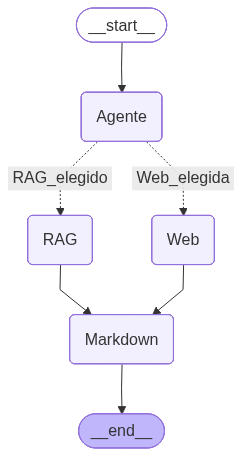

In [81]:
from IPython.display import Image, display

imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))

In [82]:
def ejecutar_agente(pregunta):

  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta":""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final


In [83]:
import markdown
from fpdf import FPDF
from google.colab import files

def descargar_resultados(texto_markdown, nombre_archivo="resultado_agente"):
  ruta_md = f"{nombre_archivo}.md"
  with open(ruta_md, "w", encoding="utf-8") as f:
    f.write(texto_markdown)

  ruta_pdf = f"{nombre_archivo}.pdf"

  html_content = markdown.markdown(texto_markdown, extensions=['tables', 'sane_lists'])

  pdf = FPDF()
  pdf.add_page()
  pdf.set_auto_page_break(auto=True, margin=15)

  try:
    pdf.write_html(html_content)
    pdf.output(ruta_pdf)
  except Exception as e:
    print(f"⚠️Hubo un pequeño problema al renderizar el PDF: {e}")

  print("⏳Iniciando descargas...")
  files.download(ruta_md)
  files.download(ruta_pdf)
  print(f"✅ Archivos '{ruta_md}' y '{ruta_pdf}' generados con éxito.")

In [84]:
import re

def generar_nombre_archivo(texto, max_longitud=40):
  """
  Toma una frase, la limpia de caracteres especiales y devuelve
  un string seguro para usar como nombre de archivo.
  """
  nombre = texto.lower()
  nombre = re.sub(r'[^\w\s]', '', nombre)
  nombre = re.sub(r'\s+', '_', nombre.strip())
  nombre_seguro = nombre[:max_longitud]

  return nombre_seguro if nombre_seguro else "consulta_agente"

In [85]:
pregunta_usuario = input("🤖 Hola! Soy tu agente de AI. ¿Qué deseas saber?\n> ")

if pregunta_usuario.strip():
  nombre_dinamico = generar_nombre_archivo(pregunta_usuario)

  print("\n" + "="*60)
  print(f"Procesando consulta...")
  print(f"Los resultados se guardarán como: {nombre_dinamico}.md y .pdf")
  print("=" * 60 + "\n")

  respuesta_generada = ejecutar_agente(pregunta_usuario)

  print("\n" + "-" * 60)
  descargar_resultados(respuesta_generada, nombre_archivo=nombre_dinamico)

else:
  print("⚠️ No ingreso ninguna pregunta. Vuelve a ejecutar.")

🤖 Hola! Soy tu agente de AI. ¿Qué deseas saber?
> ¿Cuantos mundiales ha ganado Brasil?

Procesando consulta...
Los resultados se guardarán como: cuantos_mundiales_ha_ganado_brasil.md y .pdf

El agente decidió la fuente Web.
Fuente utilizada: Web
Contexto utilizado: ['Brasil es la selección más exitosa en la historia de la Copa Mundial de Fútbol; la conquistó en cinco oportunidades (1958, 1962, 1970, 1994 y 2002)\u200b\u200b y fue ...', 'Brasil es el equipo que más veces ganó la Copa Mundial de la FIFA, con cinco conquistas. Más abajo en el ranking figuran Italia y Alemania, con ...', 'Pese a sus 24 años sin títulos, Brasil sigue siendo la gran potencia en el panorama general de los Mundiales, en los que disputó 114 partidos, ...', 'Cuando BRASIL DABA MIEDO Los 5 MUNDIALES de BRASIL La selección brasileña ha conquistado cinco Copas del Mundo y, desde hace más de ...', 'Es fácil. Tiene 2 copas del mundo. En total 4 campeonatos mundiales. En ésta publicación sólo cuentan copas del mundo. 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivos 'cuantos_mundiales_ha_ganado_brasil.md' y 'cuantos_mundiales_ha_ganado_brasil.pdf' generados con éxito.
